### Spontaneous activity: LFP spectra in steady-state activity


1. Load in segments of neural recordings where no vocalizations were taking place and no playback was given ("spontaneous activity"). We had searched through the data for time windows in which at least 60 seconds of nothing was happening. 

2. Compute power spectral densities


In [ ]:
import sys, importlib, os
sys.path.append(os.path.join(sys.path[0],'../../') ) # rel. dir. to find ephystoolbox 
from glob import glob 
# my functions
from ephystoolbox import process, utils

# basics
import random
import numpy as np
import pandas as pd

# signal processing and statistics
from scipy import stats

import matplotlib.pyplot as plt
from matplotlib import rc
rc("pdf", fonttype=42)

In [ ]:
# use when plotting scalar values, i.e. you want 1 color to represent the conditions control and muscimol
pal = [plt.cm.viridis(np.linspace(0.4,0.6,1)),plt.cm.magma(np.linspace(0.4,0.6,1))]

# use when variable # of colors wanted from treatment palette
def colormap(treatment, n=16):
    if treatment=="control":
        cmap = plt.cm.viridis(np.linspace(0.4,0.9,n))    
    elif treatment=="muscimol":
        cmap = plt.cm.magma(np.linspace(0.4,0.9,n))
    return(cmap)

In [ ]:
# parameters
Fs = 1e4
channel_depths = np.arange(50,850,50) #@updated to true depth as of 20240510


In [ ]:
# processed data directories
d1_dir = './../../neural_data/LFP_spontaneous/raw_segments'
# results directory
# r1_dir = './../../../results/LFP/spontaneous'


./../../../data\cache_data/LFP_spontaneous/raw_segments ./../../../results/LFP/spontaneous


Load all data and pour into one dict.

In [ ]:
seg_data = {} 
for f in glob(d1_dir+"/*.npy"):
    print(f)
    
    fdata = {'anim#': f.rsplit('\\')[-1].rsplit('_')[2], 'contrast': f.rsplit('\\')[-1].rsplit('_')[4]}
    loaded_seg_dict = np.load(f,allow_pickle=True).all()    
    relist = [v for v in loaded_seg_dict.values()]

    if fdata['anim#'] not in seg_data.keys():
        seg_data[fdata['anim#']] = {}
        
    if fdata['contrast'] == "pre":
        seg_data[fdata['anim#']]['control'] = relist #.update({'control':relist})
    elif fdata['contrast'] == "post":
        seg_data[fdata['anim#']]['muscimol'] = relist #.update({'muscimol':relist})        
    

./../../../data\cache_data/LFP_spontaneous/raw_segments\VocalCircuits_Exp5v01-FAFmuscimol_F1_awake_post_silence_n1_2023-07-13T19-14-55_LFP_spont[60].npy
./../../../data\cache_data/LFP_spontaneous/raw_segments\VocalCircuits_Exp5v01-FAFmuscimol_F1_awake_pre_silence_n1_2023-07-13T18-10-03_LFP_spont[60].npy
./../../../data\cache_data/LFP_spontaneous/raw_segments\VocalCircuits_Exp5v01-FAFmuscimol_F2_awake_post_silence_n1_2023-07-17T15-14-36_LFP_spont[60].npy
./../../../data\cache_data/LFP_spontaneous/raw_segments\VocalCircuits_Exp5v01-FAFmuscimol_F3_awake_post_silence_n1_2023-07-21T16-18-00_LFP_spont[60].npy
./../../../data\cache_data/LFP_spontaneous/raw_segments\VocalCircuits_Exp5v01-FAFmuscimol_F3_awake_pre_silence_n1_2023-07-21T14-12-15_LFP_spont[60].npy
./../../../data\cache_data/LFP_spontaneous/raw_segments\VocalCircuits_Exp5v01-FAFmuscimol_F4_awake_post_silence_n1_2023-07-26T15-25-46_LFP_spont[60].npy
./../../../data\cache_data/LFP_spontaneous/raw_segments\VocalCircuits_Exp5v01-FAFmus

Query how many segments of data we have for each animal and in each condition, and how much total recording time we have in each cell.

In [15]:
for anim in seg_data.keys():
    print(anim)
    for treat in seg_data[anim].keys():
        print(treat + ': ' + str(len(seg_data[anim][treat])))
        l = 0
        ll = []
        for s in range(len(seg_data[anim][treat])):
            l=l+seg_data[anim][treat][s].shape[-1]/Fs
            ll.append(seg_data[anim][treat][s].shape[-1]/Fs)
            
        print(l)
        print(np.max(ll))

F1
muscimol: 1
156.9162
156.9162
control: 1
287.5848
287.5848
F2
muscimol: 2
131.69240000000002
66.1293
F3
muscimol: 5
596.5197
193.5045
control: 8
745.8159
148.7721
F4
muscimol: 5
452.77790000000005
120.9882
control: 6
603.3405
135.7345
M2
muscimol: 16
23358.400000000005
1459.9
M3
muscimol: 6
812.929
214.8736
control: 9
669.8752999999999
101.5245
M4
muscimol: 7
522.3238
85.1736
control: 1
134.2873
134.2873


Segment the loaded data by collecting chunks of data of a particular length from the recordings in each animal.

In [16]:
#sliced_seg_data = dict.fromkeys(seg_data.keys(),{})
sliced_seg_data = {}
print(sliced_seg_data)
for anim in seg_data.keys():
    print(anim)
    if anim=="M2" or anim=="F2": # no pre, so inadequate for comp.
        continue
        
    sliced_seg_data[anim] = {}
    
    for treatment in seg_data[anim].keys():
        print(treatment)
        
        d = int(Fs*5) # 5 s long segments
        
        k = 10 # desired samples
        
        sliced_seg_data[anim][treatment] = {}
        
        sliced_data = [] # collect from all segments - alternatively, you could add bits from each segment separately...
        
        # --- opt 1 ---
        # get seg lengths in samples
#         seg_lens = [s.shape[-1] for s in seg_data[anim][treatment]]
        
#         # select longest
#         sel_seg = seg_data[anim][treatment][np.argmax(seg_lens)]
        
#         N = sel_seg.shape[-1] # range
#         #d = N
#         starts_sp = np.sort(np.array(utils.sample_with_minimum_distance(n=N-(d-1), k=k,d=d)))
#         sub_segs_sp = np.vstack(((starts_sp),(starts_sp+d))).T
            
#         # segment data actually
#         for m in range(len(sub_segs_sp)):
#             sliced_data.append(sel_seg[:,sub_segs_sp[m,0]:sub_segs_sp[m,1]])   
       
        # --- opt 2 --- 
        # take segments of a particular length from all segments 
        for s in range(len(seg_data[anim][treatment])):
            print('dur (s): '+ str(np.round(seg_data[anim][treatment][s].shape[1]/Fs)))
            N = seg_data[anim][treatment][s].shape[1] # range
            starts_sp = np.sort(np.array(utils.sample_with_minimum_distance(n=N-(d-1), k=k,d=d)))
            sub_segs_sp = np.vstack(((starts_sp),(starts_sp+d))).T
            
            print('n segs: ' + str(len(sub_segs_sp)))
            
            # segment data actually
            for m in range(len(sub_segs_sp)):
                sliced_data.append(seg_data[anim][treatment][s][:,sub_segs_sp[m,0]:sub_segs_sp[m,1]])   
                
        print(sliced_data[0].shape[-1]/Fs)
        
        sliced_seg_data[anim][treatment] = sliced_data
        
sliced_seg_data

{}
F1
muscimol
dur (s): 157.0
n segs: 10
5.0
control
dur (s): 288.0
n segs: 10
5.0
F2
F3
muscimol
dur (s): 194.0
n segs: 10
dur (s): 117.0
n segs: 10
dur (s): 77.0
n segs: 10
dur (s): 123.0
n segs: 10
dur (s): 86.0
n segs: 10
5.0
control
dur (s): 102.0
n segs: 10
dur (s): 84.0
n segs: 10
dur (s): 65.0
n segs: 10
dur (s): 141.0
n segs: 10
dur (s): 149.0
n segs: 10
dur (s): 65.0
n segs: 10
dur (s): 79.0
n segs: 10
dur (s): 60.0
n segs: 10
5.0
F4
muscimol
dur (s): 72.0
n segs: 10
dur (s): 73.0
n segs: 10
dur (s): 101.0
n segs: 10
dur (s): 121.0
n segs: 10
dur (s): 86.0
n segs: 10
5.0
control
dur (s): 107.0
n segs: 10
dur (s): 81.0
n segs: 10
dur (s): 111.0
n segs: 10
dur (s): 106.0
n segs: 10
dur (s): 136.0
n segs: 10
dur (s): 63.0
n segs: 10
5.0
M2
M3
muscimol
dur (s): 82.0
n segs: 10
dur (s): 159.0
n segs: 10
dur (s): 215.0
n segs: 10
dur (s): 150.0
n segs: 10
dur (s): 93.0
n segs: 10
dur (s): 114.0
n segs: 10
5.0
control
dur (s): 68.0
n segs: 10
dur (s): 65.0
n segs: 10
dur (s): 63.0
n

{'F1': {'muscimol': [array([[-8.65978782e+00, -9.99767189e+00, -1.11195360e+01, ...,
            2.08832086e-01, -2.96670892e-01, -8.44801839e-01],
          [-4.07847723e+00, -5.35110011e+00, -6.40128410e+00, ...,
           -9.42957933e-01, -1.49448472e+00, -2.04187697e+00],
          [-7.41069602e+00, -8.77153242e+00, -9.90898302e+00, ...,
           -2.63606771e-01, -8.12689750e-01, -1.39265646e+00],
          ...,
          [-5.83196600e+02, -5.82341063e+02, -5.81224307e+02, ...,
            1.78859637e+02,  1.80668541e+02,  1.82861288e+02],
          [            nan,             nan,             nan, ...,
                       nan,             nan,             nan],
          [-5.33828967e+02, -5.34369180e+02, -5.35049669e+02, ...,
            2.24676611e+02,  2.25536524e+02,  2.26269271e+02]]),
   array([[ 6.50771991,  6.02227516,  5.61626491, ..., -6.41005526,
           -5.42855512, -4.29640952],
          [ 3.095654  ,  2.94997115,  2.89551889, ..., -7.36614688,
           

Now that we've generated N segments of length L for each animal, go in and randomly select N' of them...

In [17]:
minN = 10
samp_seg_data = {}
for anim in sliced_seg_data.keys():
    print(anim)
    samp_seg_data[anim] = {}
    for treat in sliced_seg_data[anim].keys():
        print(len(sliced_seg_data[anim][treat]))
        slice_at = np.array(random.sample(range(len(sliced_seg_data[anim][treat])),minN))
        subsect_slices = np.array(sliced_seg_data[anim][treat])[slice_at]
        samp_seg_data[anim][treat] = subsect_slices # slice x ch x timeseries


F1
10
10
F3
50
80
F4
50
60
M3
60
90
M4
70
10


Z-score LFP data for each animal across control vs. muscimol recordings. 

In [18]:
z_norm = True
samp_seg_data2 = {} 
for anim in samp_seg_data.keys():
    print(anim)
    samp_seg_data2[anim] = {}
    
    catch_for_norm = []
    for treat in samp_seg_data[anim].keys():
#         print(len(samp_seg_data[anim][treat]))
        catch_for_norm.append(samp_seg_data[anim][treat])
        np.vstack((catch_for_norm))
    
    anim_segs = np.vstack((catch_for_norm))
    # reshape by collapsing trial (sequence) and channel data to z-score along timepoints
    segs_flat = anim_segs.reshape(1,anim_segs.shape[0]*anim_segs.shape[1]*anim_segs.shape[2])
    if z_norm:
        z_vec = stats.zscore(segs_flat,axis=1,nan_policy='omit')
    else:
        z_vec = segs_flat
    anim_segs_z = z_vec.reshape(anim_segs.shape[0],anim_segs.shape[1],anim_segs.shape[2])
    
    reslice_int = np.vstack((np.arange(0,anim_segs.shape[0],minN), np.arange(0,anim_segs.shape[0],minN)+minN))
    
    for treatN in range(len(samp_seg_data[anim].keys())):
        treats = list(samp_seg_data[anim].keys())
        samp_seg_data2[anim][treats[treatN]] = anim_segs_z[reslice_int[treatN][0]:reslice_int[treatN][1],:,:]
        print(samp_seg_data2[anim][treats[treatN]].shape)


F1
(10, 16, 50000)
(10, 16, 50000)
F3
(10, 16, 50000)
(10, 16, 50000)
F4
(10, 16, 50000)
(10, 16, 50000)
M3
(10, 16, 50000)
(10, 16, 50000)
M4
(10, 16, 50000)
(10, 16, 50000)


### Plot LFP spectra

In [20]:
nfft = 4096*2
print(nfft)
nperseg = 2048
print(nperseg)
overlap = 50

8192
2048


Length of segments for psd computation are the same, so using welch's method
not a problem.

['F1', 'F3', 'F4', 'M3', 'M4']
(50, 16, 50000)
(50, 16, 50000)


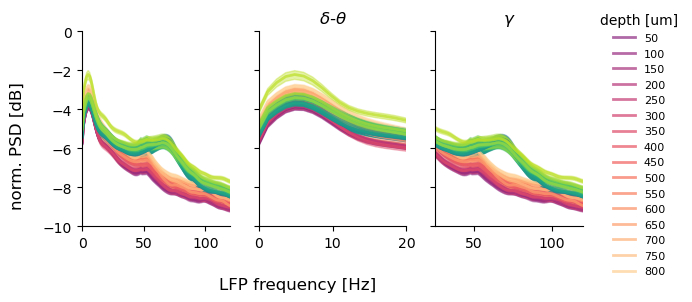

In [22]:
# average over animals
fig, ax = plt.subplots(1,3, figsize=(6,3))


anims = list(samp_seg_data2.keys())
print(anims)
for treat in samp_seg_data2[anims[0]].keys():
    segs_allanims = np.vstack(([samp_seg_data2[a][treat] for a in anims]))
    print(segs_allanims.shape)
    for ch in range(segs_allanims.shape[1]):

        psd, freq_ax = process.compute_psd(segs_allanims[:,ch,:], Fs, nperseg, overlap, nfft, True)

        cmap = colormap(treat,segs_allanims.shape[1])
        
        avg_psd = np.nanmean(psd,axis=0)
        sem_psd = stats.sem(psd,0,nan_policy="omit")
        
        ax[0].plot(freq_ax, np.log(avg_psd), color = cmap[ch], alpha = 0.7, linewidth = 2) # average of power
        ax[0].fill_between(freq_ax, np.log(avg_psd-sem_psd), np.log(avg_psd+sem_psd), alpha = 0.4, color = cmap[ch], label = '_nolegend_')
        ax[0].set_xlim([0, 120])
        ax[0].set_ylim([-10, 0])
        
        
        ax[1].plot(freq_ax, np.log(avg_psd), color = cmap[ch], alpha = 0.7, linewidth = 2) # average of power
        ax[1].fill_between(freq_ax, np.log(avg_psd-sem_psd), np.log(avg_psd+sem_psd), alpha = 0.4, color = cmap[ch], label = '_nolegend_')
        ax[1].set_xlim([0, 20])
        ax[1].set_ylim([-10, 0])
        ax[1].set_title(r"$\delta$-$\theta$")
        ax[1].label_outer()

        ax[2].plot(freq_ax, np.log(avg_psd), color = cmap[ch], alpha = 0.7, linewidth = 2) # average of power
        ax[2].fill_between(freq_ax, np.log(avg_psd-sem_psd), np.log(avg_psd+sem_psd), alpha = 0.4, color = cmap[ch], label = '_nolegend_')
        ax[2].set_xlim([25, 120])
        ax[2].set_ylim([-10, 0])
        ax[2].set_title("$\gamma$")
        ax[2].label_outer()
        
for a in ax.flatten():
    a.spines[['right','top']].set_visible(False)        
fig.supylabel('norm. PSD [dB]')
fig.supxlabel('LFP frequency [Hz]')
fig.legend(title = "depth [um]", labels = channel_depths, loc = "center right", fontsize=8, frameon=False, bbox_to_anchor=(1.15, 0.5))
fig.tight_layout()
# fig.savefig(os.path.join(r1_dir, '1_norm_psds_bychannel_.pdf'),bbox_inches = "tight")
fig.savefig(os.path.join(r1_dir, '1_norm_psds_bychannel.png'),bbox_inches = "tight")   